In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)

# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *


def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

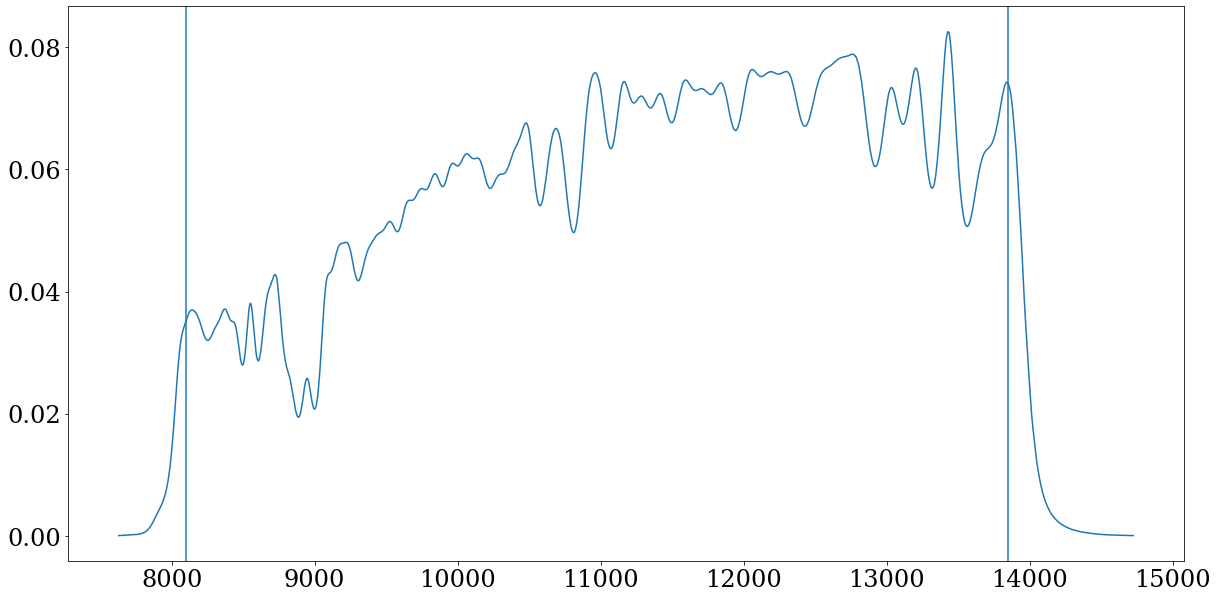

In [3]:
plt.figure(figsize=(20,10))
flt = get_filter("../data/HST_NICMOS1.F110W.dat")
plt.plot(flt[:,0], flt[:,1])
plt.axvline(8100)
plt.axvline(13850)

In [4]:
wid = 72
oversample = 4

filtname = "F160W"

nwavels = 20
npoly=nwavels
n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)
detector = NICMOSDetector(oversample, wid)

W0813 10:44:04.957015 6261400 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [5]:
nwavels

20

In [6]:
wavels, bandpass = calc_throughput(filtname, nwavels=nwavels)

In [7]:
wavels, weights = calc_throughput(filtname, nwavels)


In [8]:
data = np.load("spectrum_iterative.npy")
# weights = data#np.ones(nwavels)#np.ones_like(data["weights"])
weights=np.ones(nwavels)
# weights = (data["weights"])

# params = data["params"][()]

key_name = "key"#list(params["aberrations"].keys())[0]

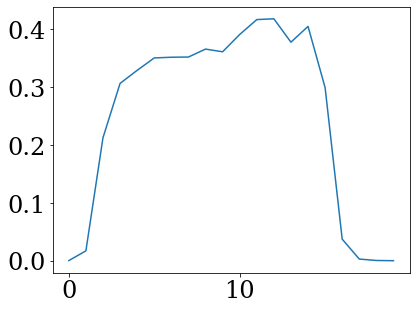

In [9]:
plt.plot(weights*bandpass)

In [10]:
weights.shape

(20,)

In [11]:
basis_weights = weights

In [12]:
spectrum_basis = np.eye(nwavels)#*bandpass
#spectrum_basis = np.load("spectrum_basis.npy")[:,:npoly]

In [13]:
exposures = [
    BlankExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname, precombined=False, wavels=wavels))
] 


In [14]:
base_params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 80.,
    "quadrature": {},
}



for idx, exp in enumerate(exposures):
    base_params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    base_params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))
    base_params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    base_params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    base_params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    base_params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    base_params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    base_params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    base_params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    base_params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    base_params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    
    base_params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    base_params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    base_params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.

params = base_params | {"spectrum": {f"{key_name}_{filtname}": basis_weights}}

injected_model = set_array(NICMOSModel(exposures, params, optics, detector))

injected_params = ModelParams(params)

In [15]:
injected_params

ModelParams(
  params={
    'positions': {'key': f64[2]},
    'spectrum': {'key_F160W': f64[20]},
    'aberrations': {'key': f64[20]},
    'cold_mask_shift': {'global': f64[2]},
    'cold_mask_rot': {'global': -45.0},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'primary_scale': {'global': f64[2]},
    'primary_rot': {'global': 45.0},
    'primary_shear': {'global': f64[2]},
    'outer_radius': 1.146,
    'secondary_radius': 0.44639999999999996,
    'spider_width': 0.0924,
    'softening': 20.0,
    'bias': {'key': 0.0},
    'jitter': {'key': 0.6511627906976745},
    'defocus': {'key': 0.0},
    'fnumber': 80.0,
    'quadrature': {'key': 0.0}
  }
)

In [16]:
exposures = [
    #InjectedExposure("test", 'F110W', SinglePointSpectrumFit(nwavels), injected_model, 287*1e-3, 10)
    InjectedExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname), injected_model, 100, 1, read_noise=0.)
]

In [17]:
# exposures = [
#     LoadedExposure(key_name, filt, SinglePointFit(np.eye(nwavels), filt, precombined=True, wavels=wavels), exp.data, exp.err, exp.bad) for exp in exposures
# ]

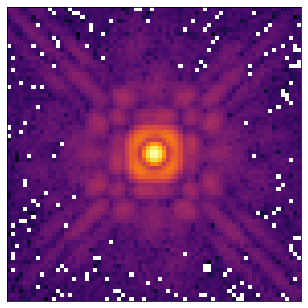

In [18]:
plt.imshow(exposures[0].data**0.125)
plt.xticks([])
plt.yticks([])
plt.tight_layout()

In [19]:
print(np.sum(exposures[0].data))

4.711180825253177


In [20]:
11811045.472931193/18717.32145868043

631.0222057683178

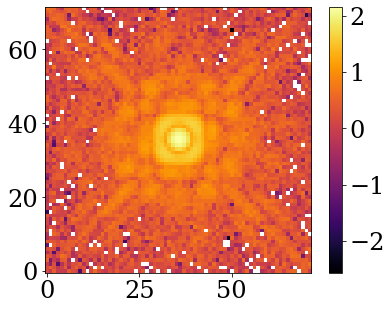

In [21]:
plt.imshow(np.log10(exposures[0].data/exposures[0].err))
plt.colorbar()

In [22]:


model = set_array(NICMOSModel(exposures, injected_params.params, optics, detector))

old_params = params
params = injected_params#ModelParams(injected_params)

In [23]:
old_params

{'positions': {'key': Array([0., 0.], dtype=float64)},
 'spectrum': {'key_F160W': Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1.], dtype=float64)},
 'aberrations': {'key': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.], dtype=float64)},
 'cold_mask_shift': {'global': Array([6., 6.], dtype=float64)},
 'cold_mask_rot': {'global': -45.0},
 'cold_mask_scale': {'global': Array([1., 1.], dtype=float64)},
 'cold_mask_shear': {'global': Array([0., 0.], dtype=float64)},
 'primary_scale': {'global': Array([1., 1.], dtype=float64)},
 'primary_rot': {'global': 45.0},
 'primary_shear': {'global': Array([0., 0.], dtype=float64)},
 'outer_radius': 1.146,
 'secondary_radius': 0.44639999999999996,
 'spider_width': 0.0924,
 'softening': 20.0,
 'bias': {'key': 0.0},
 'jitter': {'key': 0.6511627906976745},
 'defocus': {'key': 0.0},
 'fnumber': 80.0,
 'quadrature': {'key': 0.0}}

In [24]:
model

NICMOSModel(
  params={
    'aberrations': {'key': f64[20]},
    'bias': {'key': f64[]},
    'cold_mask_rot': {'global': f64[]},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'key': f64[]},
    'fnumber': f64[],
    'jitter': {'key': f64[]},
    'outer_radius': f64[],
    'positions': {'key': f64[2]},
    'primary_rot': {'global': f64[]},
    'primary_scale': {'global': f64[2]},
    'primary_shear': {'global': f64[2]},
    'quadrature': {'key': f64[]},
    'secondary_radius': f64[],
    'softening': f64[],
    'spectrum': {'key_F160W': f64[20]},
    'spider_width': f64[]
  },
  filters={'F160W': f64[238,2]},
  optics=NICMOSFresnelOptics(
    wf_npixels=512,
    diameter=f64[],
    layers={
      'CompoundAperture':
      CompoundAperture(
        normalise=True,
        transformation=CoordTransform(
          translation=None, rotation=f64[], compression=None, shear=None
        ),
     

In [25]:
model_forecast = injected_params.inject(model)

In [26]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))

spec_params = ModelParams({"spectrum": injected_params.get("spectrum")})

f = lambda params: loss_fn(ModelParams(injected_params.params | params.params), exposures, params.inject((model)))
F, unflatten = zdx.batching.hessian(f, spec_params, nbatches=20*len(exposures))

# S_inv = 1.0 / np.sqrt(np.diag(F))
# F = S_inv[:, None] * F * S_inv[None, :]

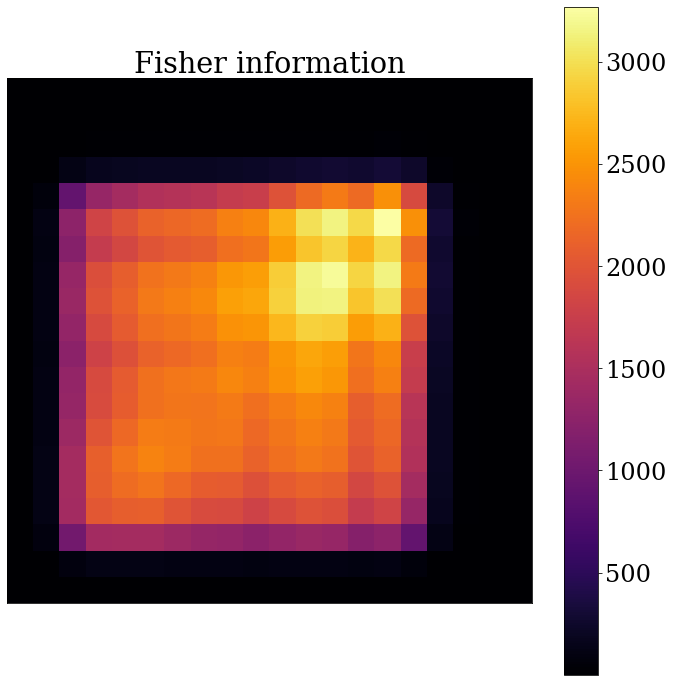

In [27]:
plt.figure(figsize=(10,10))
plt.imshow(F, interpolation='none')
plt.title("Fisher information")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.tight_layout()

In [28]:
np.sum(np.abs(F - F.T)**2)

Array(1.19667088e-21, dtype=float64)

In [29]:
np.min(F)

Array(0.00217768, dtype=float64)

In [30]:
np.linalg.inv(F)

Array([[ 5.59816317e+07, -1.50979292e+07,  7.09482520e+06,
        -2.09007103e+07,  6.66653061e+07, -1.80242121e+08,
         4.43734788e+08, -9.49117087e+08,  1.70165739e+09,
        -2.79344668e+09,  3.62539372e+09, -4.11855665e+09,
         4.24236625e+09, -4.08857076e+09,  2.74497084e+09,
        -2.15425642e+09,  7.71516478e+09, -3.01627009e+10,
         2.90095669e+10, -6.83155108e+09],
       [-1.51493047e+07,  4.10973668e+06, -1.93931307e+06,
         5.73043362e+06, -1.83204965e+07,  4.96247821e+07,
        -1.22356285e+08,  2.62045982e+08, -4.70332528e+08,
         7.72834507e+08, -1.00384158e+09,  1.14124466e+09,
        -1.17633818e+09,  1.13437730e+09, -7.62010796e+08,
         5.98323782e+08, -2.14377608e+09,  8.38456613e+09,
        -8.06694136e+09,  1.90031342e+09],
       [ 7.14195717e+06, -1.94553458e+06,  9.20943615e+05,
        -2.72778755e+06,  8.73737650e+06, -2.37035119e+07,
         5.85197010e+07, -1.25468316e+08,  2.25413650e+08,
        -3.70707612e+08,  4.8

In [31]:
np.real(np.linalg.eig(F)[0].sort()[::-1])

Array([3.03413374e+04, 2.55470333e+03, 7.09289172e+02, 2.41117903e+02,
       9.51123876e+01, 3.40395185e+01, 1.48223350e+01, 4.20421805e+00,
       7.47030865e-01, 1.28173684e-01, 2.91392848e-02, 4.21407065e-03,
       6.45652348e-04, 4.08649822e-05, 3.46125384e-06, 6.90565381e-07,
       4.54726360e-08, 1.12294676e-09, 2.62817167e-11, 2.09218537e-14],      dtype=float64)

Text(0, 0.5, 'Eigenvalue')

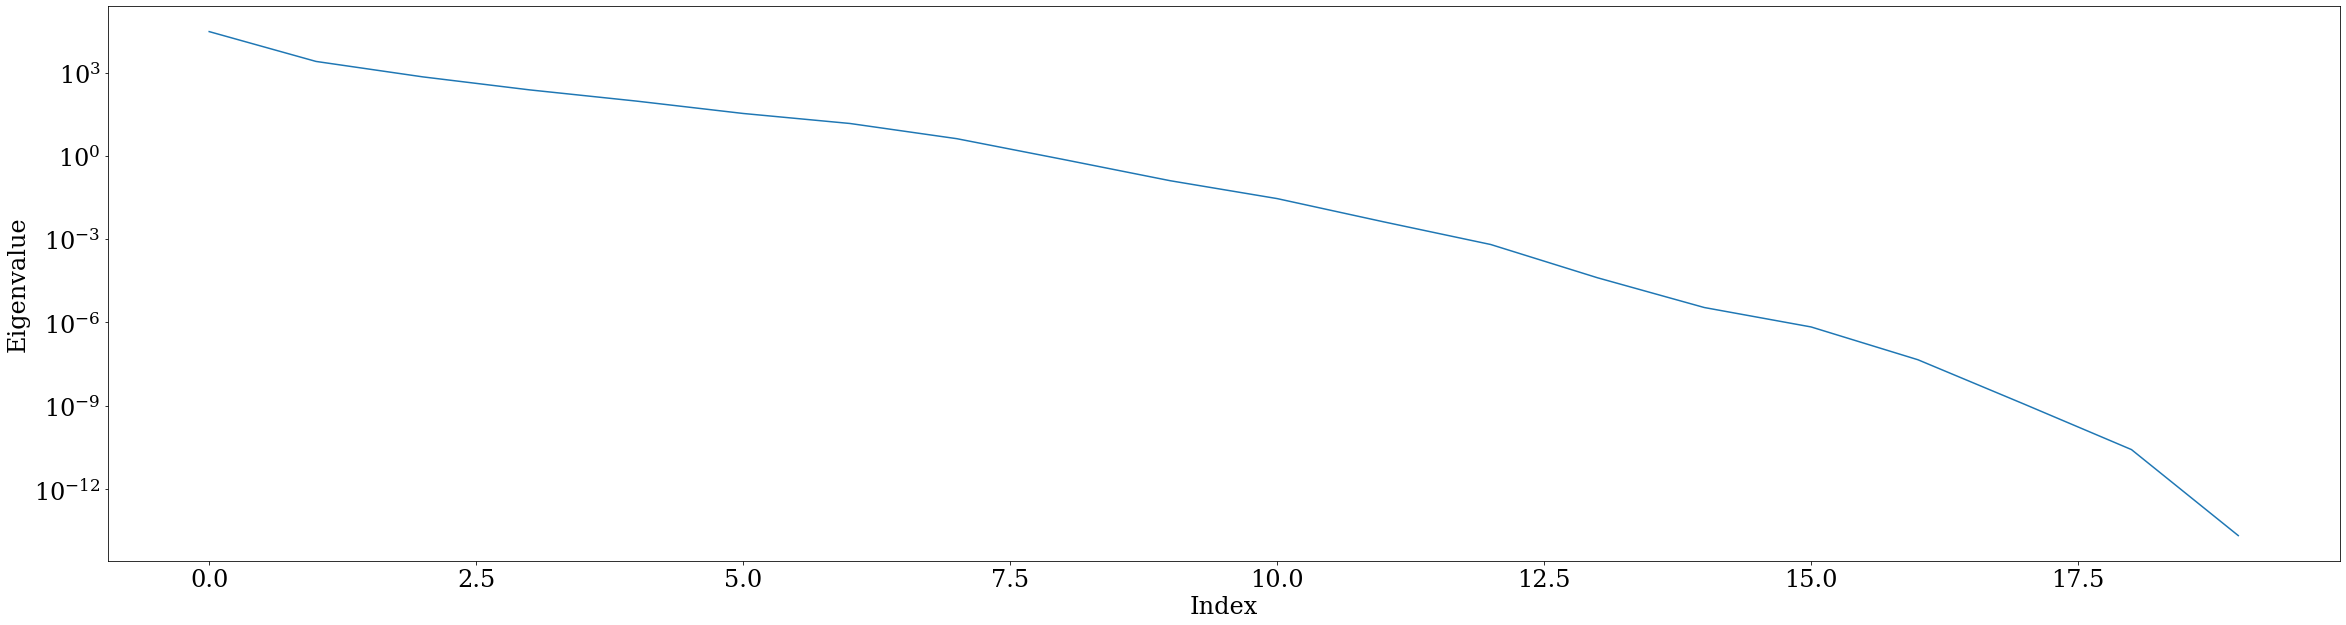

In [32]:
plt.figure(figsize=(40,10))
plt.semilogy(np.real(np.linalg.eig(F)[0].sort()[::-1])[:50])
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

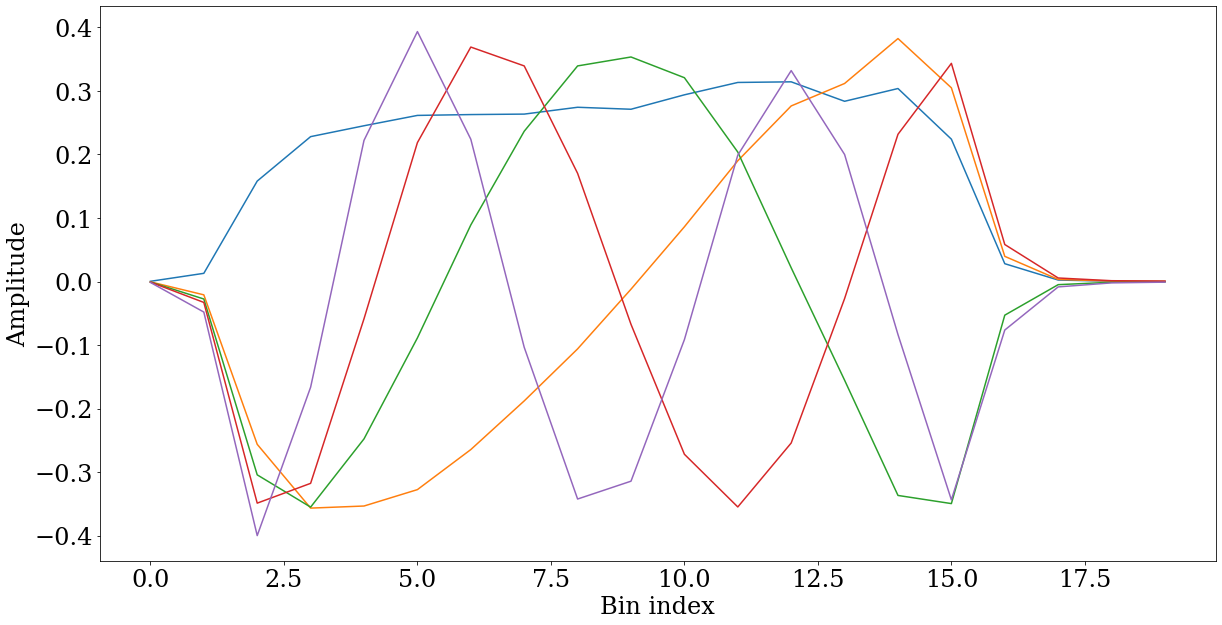

In [33]:
vals, vects = np.linalg.eig(F)

order = np.argsort(vals)[::-1]

plt.figure(figsize=(20,10))
plt.xlabel("Bin index")
plt.ylabel("Amplitude")

for i in range(5):
    plt.plot(np.real(vects[:,order[i]]))

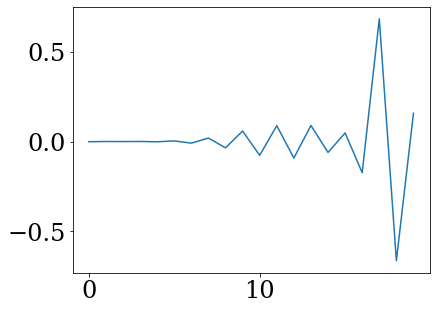

In [34]:
plt.plot(np.real(vects[:,order[-1]]))

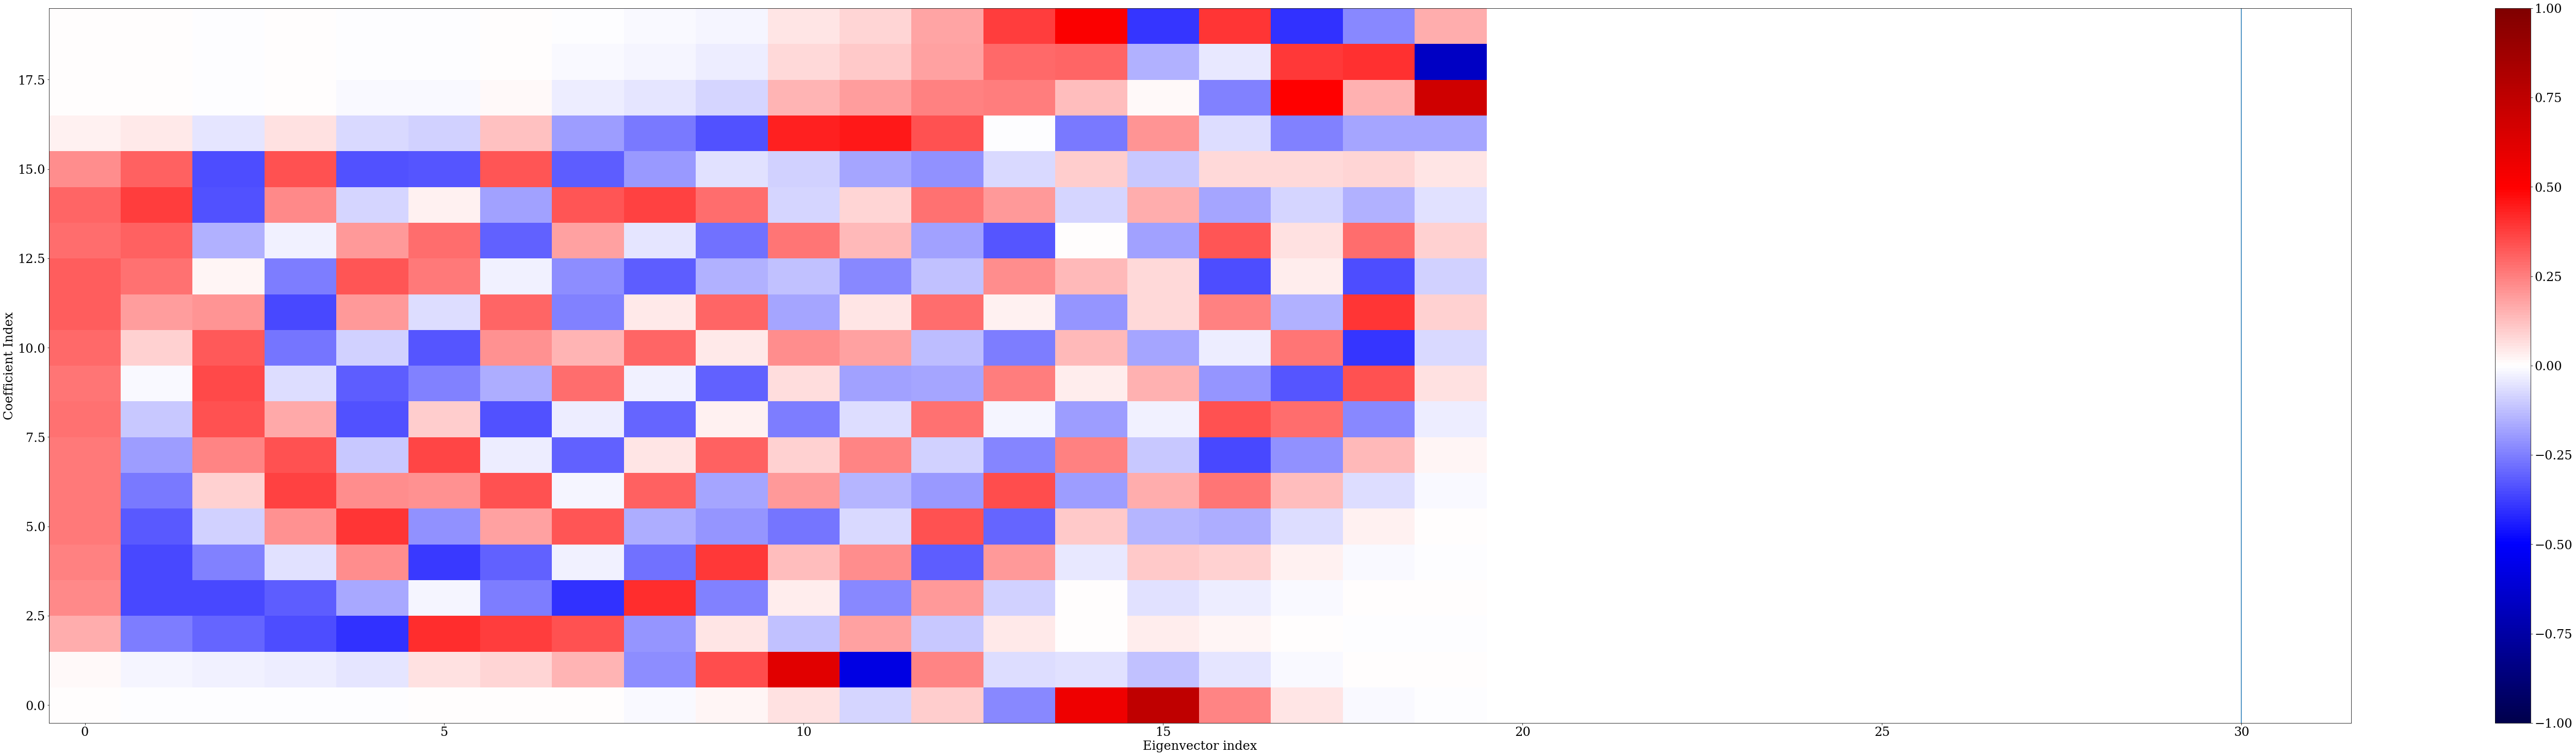

In [35]:
plt.figure(figsize=(20*5,5*5))
plt.imshow(np.real(vects[:,order[:]]), cmap='seismic', vmax=1, vmin=-1, interpolation='none', aspect='auto')
plt.xlabel("Eigenvector index")
plt.ylabel("Coefficient Index")
plt.colorbar()
plt.axvline(30)

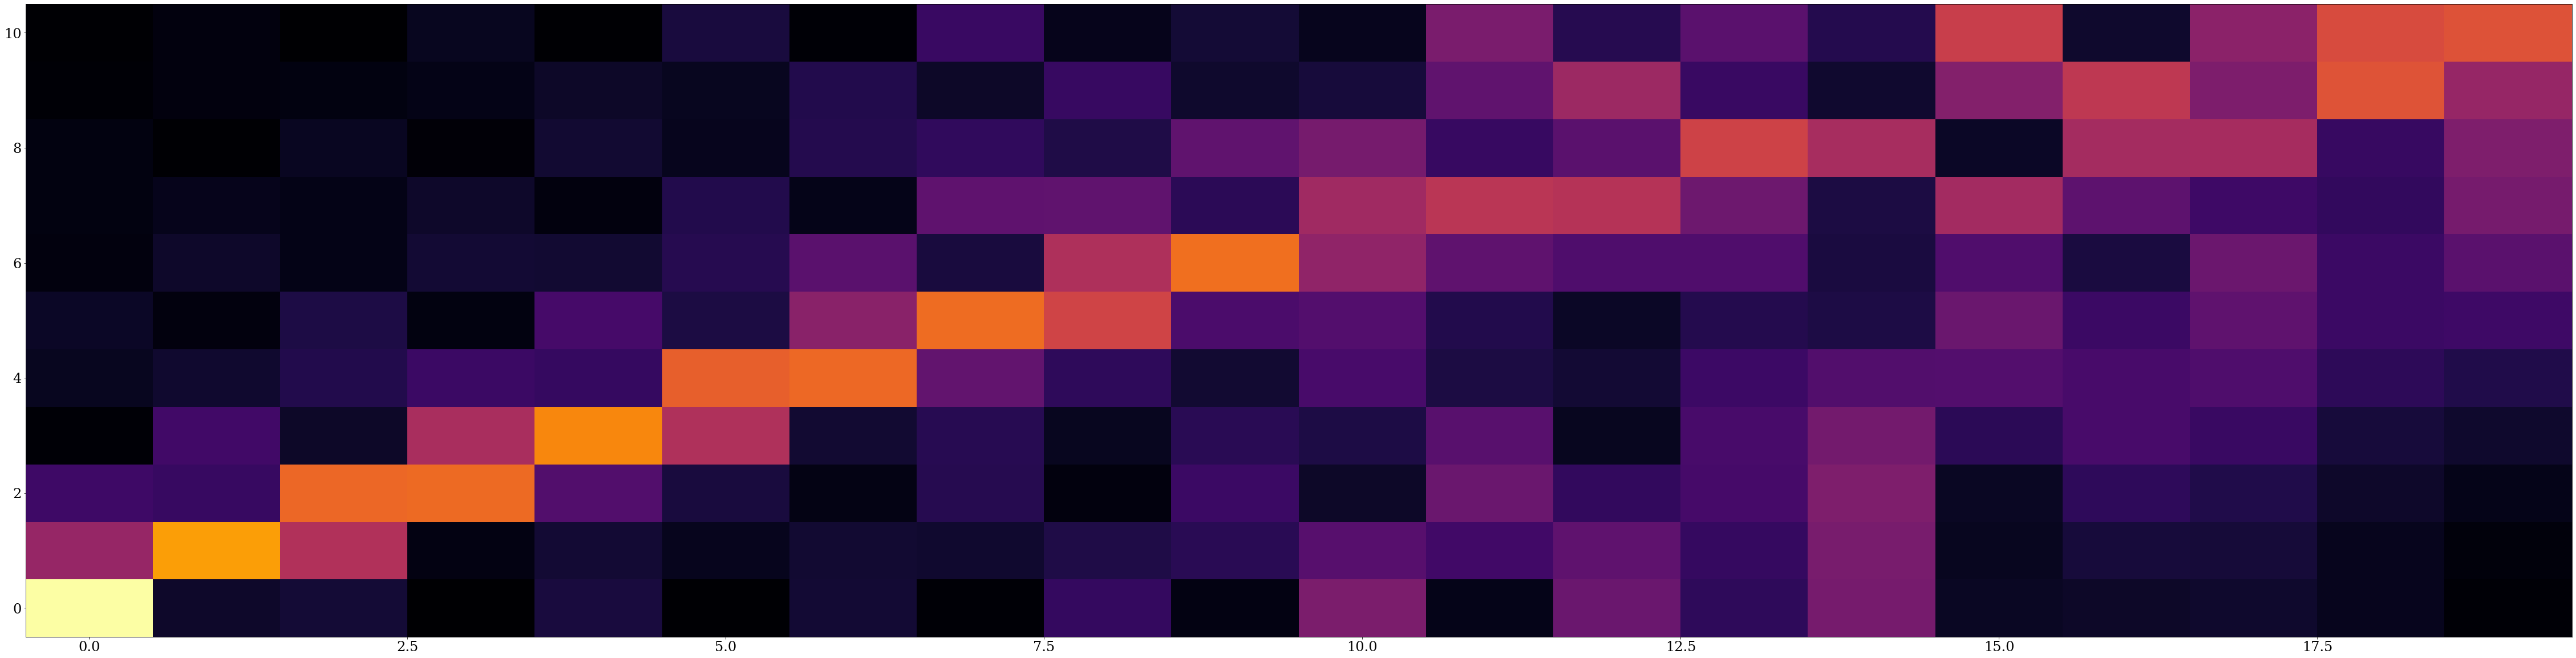

In [36]:
plt.figure(figsize=(20*4, 5*4))
modal_spectrum = np.abs(np.fft.rfft(np.real(vects[:,order[:50]]), axis=0))
plt.imshow(modal_spectrum, aspect='auto')

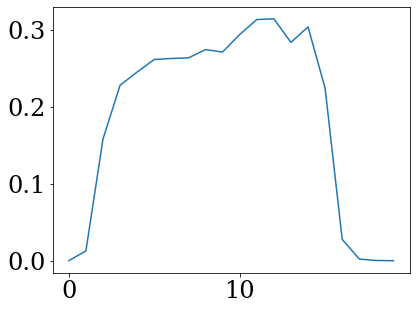

In [37]:
plt.plot(np.real(vects[:,order[0]]))

In [38]:
vcts = np.real(vects[:,order])
if np.mean(vcts[:,0]) < 0:
    vects_adj = vcts*np.ones(nwavels).at[0].mul(-1)
    print("yes")
else:
    vects_adj=vcts
numpy.save(f"../data/iterative_spectrum_basis_{filtname}.npy", vects_adj)

In [39]:
stop

NameError: name 'stop' is not defined

In [ ]:
for i in range(35):
    vects = vects.at[:, order[i]].mul(np.sign(np.mean(vects[:30, order[i]])))

/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_6466/1232554602.py:15: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0)


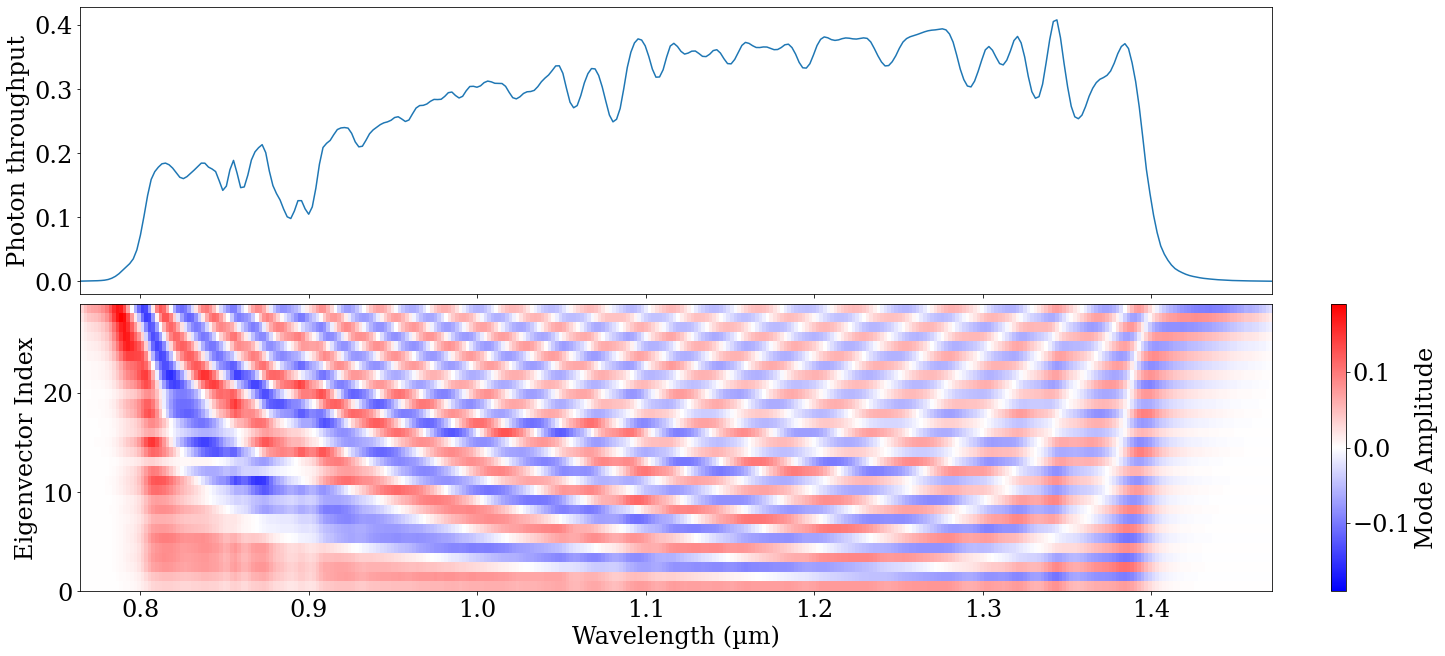

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(20,9), layout='compressed', sharex=True, gridspec_kw={'hspace': 0})
wvs = wavels/1e-6
axs[0].plot(wvs, bandpass)
axs[0].set_ylabel("Photon throughput")
axs[0].set_xlim(np.min(wvs), np.max(wvs))
# axs[0].set_xticks([])

vm = np.max(np.real(vects[:,order[:30]]).T)

im = axs[1].imshow(np.real(vects[:,order[:30]]).T, cmap='bwr', extent=(np.min(wvs), np.max(wvs), 0, 29), vmax=vm, vmin=-vm, interpolation='none', aspect='auto')
# axs[1].set_xlabel("Coefficient index")
axs[1].set_xlabel("Wavelength (µm)")
axs[1].set_ylabel("Eigenvector Index")
fig.colorbar(im, ax=axs[1], label="Mode Amplitude")
fig.subplots_adjust(hspace=0)


plt.savefig("eigenbasis.pdf")
# fig.tight_layout()